# Hi-LASSO 재현 (v2)

논문 *Hi-LASSO*(IEEE Access 2019) Table 3의 **Hi-LASSO**를 재현한다.
Random LASSO의 2단계 부트스트랩 + 4개선: 편향교정(nanmean)·정교한 중요도·Adaptive Proc2·**이항 유의성 검정**(임계값 불필요).
데이터·채점은 `lib/`(generate_data·scoring) 재사용, 솔버는 `lib/hi_lasso.py`. R 불필요.

# Part A · 준비

## 1. 환경 & 모듈 import

R 불필요(내부 솔버 = sklearn ElasticNetCV/LassoCV).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join("..", "lib")))
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings; warnings.filterwarnings("ignore")

import generate_data as gd
from generate_data import DATASETS, SIGMA, BASE_SEED, SEED_BETA, build_beta, generate_split, snr
import scoring
from scoring import rme, rme_nonzeros, rmse, f1_selection, aucpr
import hi_lasso
from hi_lasso import fit_hi_lasso

print("modules loaded (R 불필요, 내부 솔버 = sklearn)")

modules loaded (R 불필요, 내부 솔버 = sklearn)


## 2. 전역 설정

선택은 **이항 유의성 검정**(alpha)이라 임계값·검증셋이 필요 없다.

In [2]:
METHOD    = "HiLASSO"
N_REPEAT  = 10
L         = 30          # 부트스트랩 배수 B=floor(L*p/q)
ALPHA     = 0.05        # 유의성 검정 유의수준
N_JOBS    = 64          # 병렬 코어 (공유서버 배려)
DATASETS_RL = {k: DATASETS[k] for k in ["Dataset I", "Dataset II", "Dataset III", "Dataset IV"]}
print("대상:", list(DATASETS_RL.keys()), "| L=%d, alpha=%.2f, N_REPEAT=%d" % (L, ALPHA, N_REPEAT))

대상: ['Dataset I', 'Dataset II', 'Dataset III', 'Dataset IV'] | L=30, alpha=0.05, N_REPEAT=10


## 3. lib 검산 & 부트스트랩 수

In [3]:
for name, cfg in DATASETS_RL.items():
    beta = build_beta(cfg)
    print("%-11s p=%-5d n_tr=%-4d SNR=%.3f  B=floor(L*p/n)=%d" % (
        name, cfg["p"], cfg["n_tr"], snr(cfg, beta), (L*cfg["p"])//cfg["n_tr"]))

Dataset I   p=100   n_tr=50   SNR=2.733  B=floor(L*p/n)=60
Dataset II  p=1000  n_tr=100  SNR=4.419  B=floor(L*p/n)=300
Dataset III p=10000 n_tr=200  SNR=4.419  B=floor(L*p/n)=1500
Dataset IV  p=10000 n_tr=400  SNR=4.419  B=floor(L*p/n)=750


# Part B · 한 번 돌려보기

## 4. 단일 데모 — 중요도 점수 (rep 0)

Procedure 1(ElasticNet)이 참 비영 변수(초록)에 높은 중요도를 주는지.

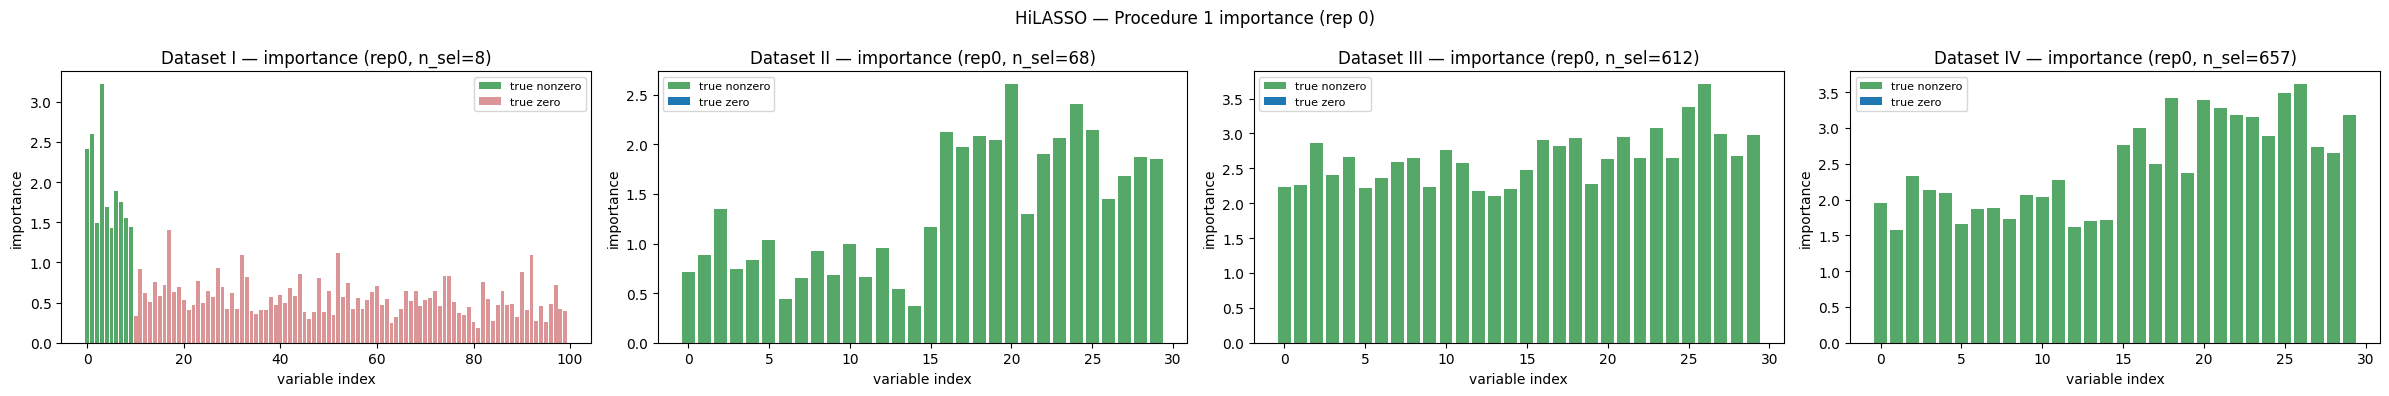

In [4]:
fig, axes = plt.subplots(1, len(DATASETS_RL), figsize=(6*len(DATASETS_RL), 4))
for ax, (name, cfg) in zip(np.atleast_1d(axes), DATASETS_RL.items()):
    beta = build_beta(cfg)
    (Xtr, ytr), _, _ = generate_split(cfg, beta, 0)
    r = fit_hi_lasso(Xtr, ytr, L=L, alpha=ALPHA, n_jobs=N_JOBS, random_state=0)
    k = 30 if cfg["p"] > 100 else cfg["p"]
    idx = np.arange(k); true = (beta[:k] != 0)
    ax.bar(idx[true], r["importance_"][:k][true], color="#55A868", label="true nonzero")
    ax.bar(idx[~true], r["importance_"][:k][~true], color="#C44E52", alpha=0.6, label="true zero")
    ax.set_xlabel("variable index"); ax.set_ylabel("importance")
    ax.set_title(f"{name} — importance (rep0, n_sel={r['n_selected']})")
    ax.legend(fontsize=8)
fig.suptitle(f"{METHOD} — Procedure 1 importance (rep 0)")
plt.tight_layout(); plt.show()

## 5. β̂ vs β — rep 0

상관 그룹의 음수 계수 β₃·β₆·β₁₀를 Hi-LASSO가 살리는지 미리보기(§11에서 10회로).

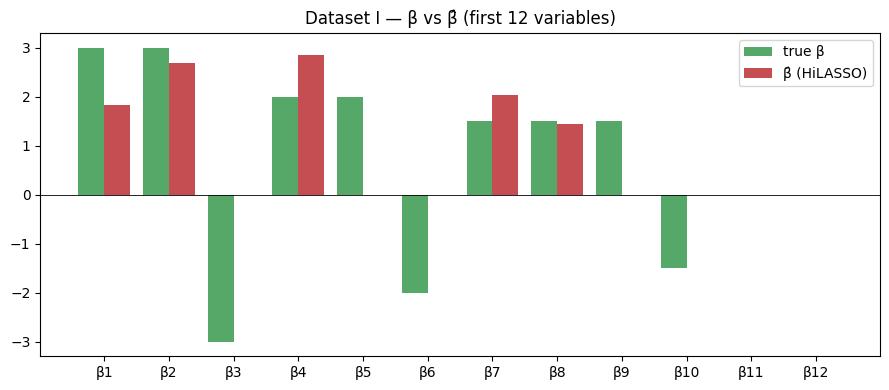

In [5]:
cfg = DATASETS_RL["Dataset I"]; beta = build_beta(cfg)
(Xtr, ytr), _, _ = generate_split(cfg, beta, 0)
r = fit_hi_lasso(Xtr, ytr, L=L, alpha=ALPHA, n_jobs=N_JOBS, random_state=0); bhat = r["coef_"]
k = 12; idx = np.arange(k); w = 0.4
plt.figure(figsize=(9, 4))
plt.bar(idx - w/2, beta[:k], w, label="true β", color="#55A868")
plt.bar(idx + w/2, bhat[:k], w, label=f"β̂ ({METHOD})", color="#C44E52")
plt.axhline(0, color='k', lw=0.6); plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title("Dataset I — β vs β̂ (first 12 variables)")
plt.legend(); plt.tight_layout(); plt.show()

# Part C · 본 실험 (10회)

## 6. 전체 실험 루프

rep마다 `fit_hi_lasso(Xtr,ytr)` → 채점(선택=유의성 검정). bhat·importance·n_selected 저장.

In [6]:
def run_experiment():
    records, details = [], {}
    for name, cfg in DATASETS_RL.items():
        beta = build_beta(cfg)
        d = dict(beta=beta, bhats=[], beta_hats=[], importances=[], n_selected=[])
        for rep in range(N_REPEAT):
            (Xtr, ytr), _, (Xte, yte) = generate_split(cfg, beta, rep)
            r = fit_hi_lasso(Xtr, ytr, L=L, alpha=ALPHA, n_jobs=N_JOBS, random_state=rep)
            bhat = r["coef_"]; pred = Xte @ bhat
            records.append(dict(dataset=name, method=METHOD, rep=rep,
                                RME_All=rme(bhat, beta, cfg),
                                RME_Nonzeros=rme_nonzeros(bhat, beta, cfg),
                                RMSE=rmse(yte, pred),
                                aucpr=aucpr(r["beta_hat_"], beta),
                                **f1_selection(bhat, beta)))
            d["bhats"].append(bhat); d["beta_hats"].append(r["beta_hat_"])
            d["importances"].append(r["importance_"]); d["n_selected"].append(r["n_selected"])
        details[name] = d
        print(f"{name}: {N_REPEAT} reps done")
    return records, details

records, details = run_experiment()
df = pd.DataFrame(records)
metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1", "aucpr"]
print("총 레코드:", len(records))

Dataset I: 10 reps done


Dataset II: 10 reps done


Dataset III: 10 reps done


Dataset IV: 10 reps done
총 레코드: 40


In [7]:
# 05 비교 노트북용: per-rep 지표(CSV) + beta_hats(NPZ) 저장
df.to_csv("../results_hi_lasso.csv", index=False)
np.savez_compressed("../results_hi_lasso.npz",
    **{f"{k}__beta_hats": np.array(v["beta_hats"]) for k, v in details.items()},
    **{f"{k}__beta": v["beta"] for k, v in details.items()})
print("saved: ../results_hi_lasso.csv + .npz")

saved: ../results_hi_lasso.csv + .npz


## 7. 결과 표 (평균 ± 표준오차)

In [8]:
summary = df.groupby(["dataset", "method"])[metrics].agg(["mean", "sem"]).round(4)
summary

RME_All         RME_Nonzeros             RMSE          \
                        mean     sem         mean     sem     mean     sem   
dataset     method                                                           
Dataset I   HiLASSO   0.7110  0.0723       0.5793  0.0647   3.8955  0.3275   
Dataset II  HiLASSO  13.1634  1.1400      11.9130  1.1770  10.7380  0.6124   
Dataset III HiLASSO  92.7424  7.5436      83.8766  7.4795  28.0706  1.5294   
Dataset IV  HiLASSO  26.4531  1.5164      23.0299  1.5370  15.7207  0.7727   

                         f1           aucpr          
                       mean     sem    mean     sem  
dataset     method                                   
Dataset I   HiLASSO  0.5983  0.0272  0.7631  0.0270  
Dataset II  HiLASSO  0.4183  0.0147  0.5846  0.0259  
Dataset III HiLASSO  0.1297  0.0049  0.7837  0.0335  
Dataset IV  HiLASSO  0.1310  0.0032  0.7923  0.0147

## 8. 논문 Table 3 비교 (Hi-LASSO 열)

In [9]:
PAPER_HILASSO = {   # 논문 Table 3, Hi-LASSO 열
    "Dataset I":   dict(RME_All=0.8513, RME_Nonzeros=0.6764, RMSE=3.3108, f1=0.4781),
    "Dataset II":  dict(RME_All=1.8608, RME_Nonzeros=1.6953, RMSE=5.3235, f1=0.2291),
    "Dataset III": dict(RME_All=1.7877, RME_Nonzeros=1.6626, RMSE=5.1963, f1=0.5147),
    "Dataset IV":  dict(RME_All=1.3592, RME_Nonzeros=1.2997, RMSE=4.5800, f1=0.6085),
}
paper_metrics = ["RME_All", "RME_Nonzeros", "RMSE", "f1"]
rows = []
for ds in DATASETS_RL:
    if ds not in PAPER_HILASSO: continue
    ours = df[df.dataset == ds][paper_metrics].mean()
    for m in paper_metrics:
        rows.append(dict(dataset=ds, metric=m, ours=round(float(ours[m]), 4), paper=PAPER_HILASSO[ds][m]))
compare = pd.DataFrame(rows)
compare["ratio(ours/paper)"] = (compare["ours"] / compare["paper"]).round(2)
compare

,dataset,metric,ours,paper,ratio(ours/paper)
0,Dataset I,RME_All,0.7110,0.8513,0.84
1,Dataset I,RME_Nonzeros,0.5793,0.6764,0.86
2,Dataset I,RMSE,3.8955,3.3108,1.18
3,Dataset I,f1,0.5983,0.4781,1.25
4,Dataset II,RME_All,13.1634,1.8608,7.07
5,Dataset II,RME_Nonzeros,11.9130,1.6953,7.03
6,Dataset II,RMSE,10.7380,5.3235,2.02
7,Dataset II,f1,0.4183,0.2291,1.83
8,Dataset III,RME_All,92.7424,1.7877,51.88
9,Dataset III,RME_Nonzeros,83.8766,1.6626,50.45


# Part D · 분포 시각화

## 9. 지표 막대 (평균 ± 표준오차)

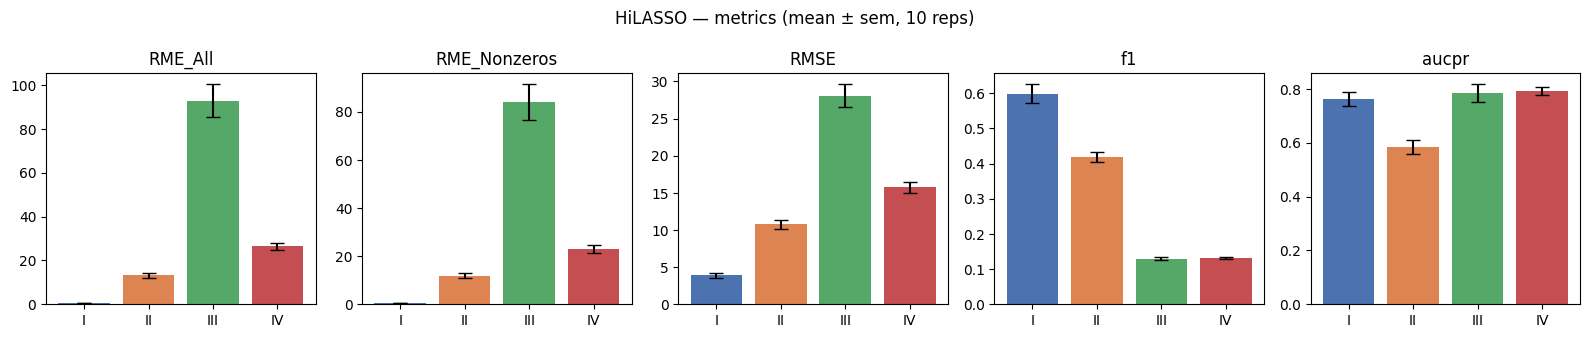

In [10]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 3.4))
for ax, m in zip(axes, metrics):
    sub = df.groupby("dataset")[m].agg(["mean", "sem"])
    ax.bar(range(len(sub)), sub["mean"], yerr=sub["sem"], capsize=5, color=colors[:len(sub)])
    ax.set_xticks(range(len(sub))); ax.set_xticklabels([s.replace("Dataset ","") for s in sub.index]); ax.set_title(m)
fig.suptitle(f"{METHOD} — metrics (mean ± sem, {N_REPEAT} reps)")
plt.tight_layout(); plt.show()

## 10. 지표 분포 박스플롯 (10회)

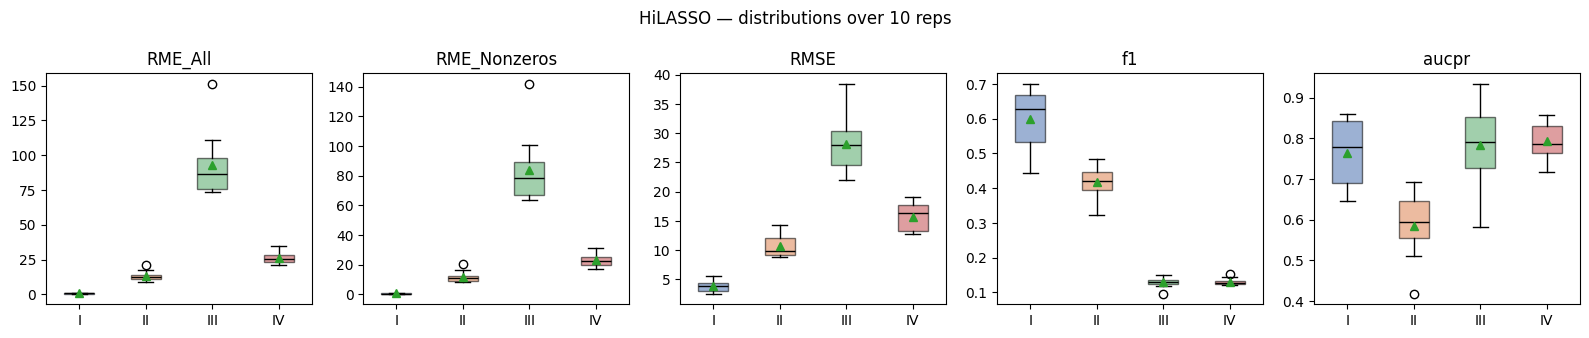

In [11]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 3.4))
for ax, m in zip(axes, metrics):
    data = [df[df.dataset == ds][m].values for ds in DATASETS_RL]
    bp = ax.boxplot(data, patch_artist=True, showmeans=True, medianprops=dict(color='k'))
    for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c); patch.set_alpha(0.55)
    ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels([s.replace("Dataset ","") for s in DATASETS_RL], ); ax.set_title(m)
fig.suptitle(f"{METHOD} — distributions over {N_REPEAT} reps")
plt.tight_layout(); plt.show()

## 11. 계수 부호 산점도 (10회)

Hi-LASSO가 음수 계수 β₃·β₆·β₁₀를 LASSO/Random보다 잘 살리는지가 관전 포인트.

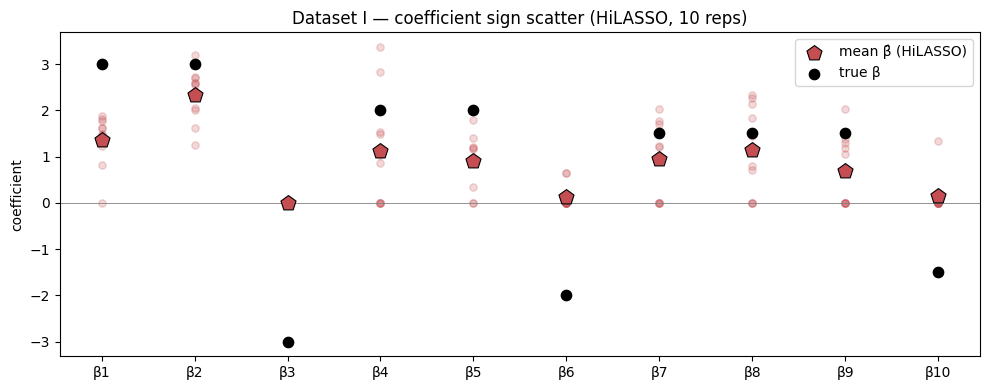

In [12]:
k = 10; d = details["Dataset I"]; beta_I = d["beta"]
bhats = np.array([bh[:k] for bh in d["bhats"]])
idx = np.arange(k)
plt.figure(figsize=(10, 4))
for rep in range(N_REPEAT):
    plt.scatter(idx, bhats[rep], color="#C44E52", alpha=0.22, s=28, zorder=2)
plt.scatter(idx, bhats.mean(0), color="#C44E52", marker='p', s=130, edgecolor='k', lw=0.8, zorder=3, label=f"mean β̂ ({METHOD})")
plt.scatter(idx, beta_I[:k], color='k', marker='o', s=55, zorder=4, label="true β")
plt.axhline(0, color='gray', lw=0.6); plt.xticks(idx, [f"β{i+1}" for i in idx])
plt.title(f"Dataset I — coefficient sign scatter ({METHOD}, {N_REPEAT} reps)")
plt.ylabel("coefficient"); plt.legend(); plt.tight_layout(); plt.show()

## 12. 선택 변수 수 분포 (10회)

유의성 검정이 반복마다 몇 개를 선택하나. 점선 = 참 비영 개수(과다/과소선택 확인).

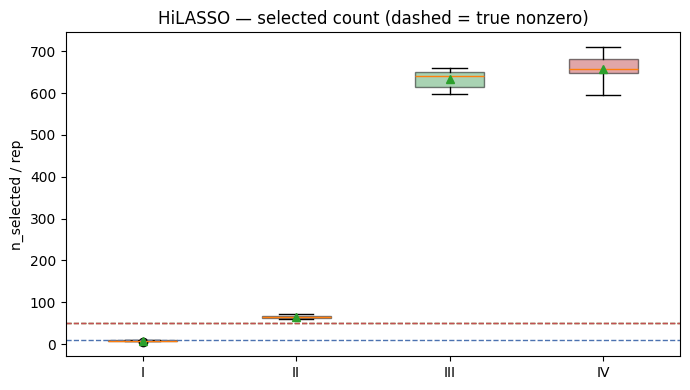

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
data = [details[name]["n_selected"] for name in DATASETS_RL]
bp = ax.boxplot(data, patch_artist=True, showmeans=True)
cs = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for patch, c in zip(bp['boxes'], cs): patch.set_facecolor(c); patch.set_alpha(0.5)
for i, name in enumerate(DATASETS_RL):
    ax.axhline(int((details[name]["beta"] != 0).sum()), color=cs[i], ls="--", lw=1)
ax.set_xticks(range(1, len(DATASETS_RL)+1)); ax.set_xticklabels([s.replace("Dataset ","") for s in DATASETS_RL])
ax.set_ylabel("n_selected / rep"); ax.set_title(f"{METHOD} — selected count (dashed = true nonzero)")
plt.tight_layout(); plt.show()